In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler,
    KBinsDiscretizer,
    Binarizer,
    LabelEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)
import warnings
warnings.filterwarnings(action='ignore')

In [26]:
# set random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [27]:
# Configure 
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [38]:
class MLPipelineWithDiscretization:
    """
    This class encapsulates the entire ML workflow including:
    - Data Loading & exploration
    - Feature engineering with preprocessing
    - Train-test split 
    - Model training with hyperparameter tuning
    - Comprehensive performace evaluation
    """

    def __init__(self, random_state=RANDOM_STATE):
        """ Initialize the pipeline with configuration"""
        self.random_state = RANDOM_STATE
        self.data = None
        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.pipeline = None
        self.best_model = None
        self.feature_names = None

    def load_data(self):
        """ Load and prepare the dataset."""
        print("\n="*80)
        print("Step 1: DATA LOADING AND EXPLORATION")
        print("="*80)

        # Load breast cancer dataset.
        cancer = load_breast_cancer()
        df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
        df['target'] = cancer.target
        self.X = df.drop(columns=['target'], axis=1)
        self.y = df['target']

        print(f"\nDataset Shape: {self.X.shape}")
        print(f"\nTarget Distribution: {self.y.value_counts()}")
        print(f"\nClass Balance: {self.y.value_counts(normalize=True)}")

        print("\nFirst 5 rows:")
        print(self.X.head())

        print("\nDataset statistics:")
        print(self.X.describe())

        print("\nMissing values:")
        print(self.X.isnull().sum().sum())

        return self

    def perform_eda(self):
        """ Perform exploratory data analysis."""
        print("\n="*80)
        print("Step 2: EXPLORATORY DATA ANALYSIS")
        print("="*80)

        # Feature correlation analysis
        correlations = self.X.corrwith(self.y).abs().sort_values(ascending=False).head(10)
        print(correlations)

        # Feature statistics by class
        print("\nFeature Statistics by Target Class:")
        feature_to_analyze = 'mean radius'
        print(f"\n{feature_to_analyze}:")
        display(self.X.groupby(self.y)[feature_to_analyze].describe())

        return self

    def feature_engineering(self):
        """Create additional features for demonstration"""
        print("\n="*80)
        print("Step 3: FEATURE ENGINEERING")
        print("="*80)

        # Create feature groups for different preprocessing strategies
        self.feature_groups = {
            'to_discretize': [
                'mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness'
            ],
            'to_binarize': [
                'mean compactness', 'mean concavity', 'mean concave points'
            ],
            'to_scale': [
                'mean symmetry', 'mean fractal dimension', 
                'worst radius', 'worst texture'
            ]
        }

        print("\n Feature Preprocessing Strategy:")
        print(f"- Features to Discretize: {len(self.feature_groups['to_discretize'])}")
        print(f"- Features to Binarize: {len(self.feature_groups['to_binarize'])}")
        print(f"- Features to Scale: {len(self.feature_groups['to_scale'])}")

        return self

    def split_data(self, test_size=0.2):
        """Split the dataset into training & testing set."""
        print("\n="*80)
        print("Step 4: TRAIN TEST SPLIT")
        print("="*80)

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X,
            self.y,
            test_size=test_size,
            random_state=RANDOM_STATE,
            stratify=self.y
        )

        print(f"\nTrainig Set: {self.X_train.shape[0]}")
        print(f"Testing Set: {self.X_test.shape[0]}")
        print(f"\nTrainig Set Target Distributoin:\n{self.y_train.value_counts()}")
        print(f"\nTesting Set Target Distributoin:\n{self.y_test.value_counts()}")

        return self

    def build_pipeline(self):
        """Build preprocessing and modeling pipeline using ColumnTransformer"""
        print("\n="*80)
        print("Step 5: BUILDING ML PIPELINE WITH COLUMNTRANSFORMER")
        print("="*80)

        preprocessor = ColumnTransformer(
            transformers=[
                ('discretizer', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'), self.feature_groups['to_discretize']),
                ('binarize', Binarizer(threshold=0.1), self.feature_groups['to_binarize']),
                ('scale', StandardScaler(), self.feature_groups['to_scale'])
            ],
            remainder='passthrough'
        )

        self.pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', DecisionTreeClassifier(random_state=self.random_state))
        ])

        print("\nPipeline Structure:")
        print(self.pipeline)

        print("\nPreprocessing Steps:")
        for name, transformer, columns in preprocessor.transformers[:-1]:
            print(f"\n{name.upper()}:")
            print(f"Transformer: {transformer.__class__.__name__}")
            print(f"Features: ({len(columns)}): {columns[:3]}...")
        
        return self

    def train_model(self, use_grid_search=True):
        """Train the model with hyperparameter tuning."""
        print("\n" + "="*80)
        print("STEP 6: MODEL TRAINING")
        print("="*80)

        if use_grid_search:
            print("\nPerforming Grid Search for Hyperparameter Tuning...")

            # Define parameter grid
            param_grid = {
                'classifier__max_depth': [3, 5, 7, 10, None],
                'classifier__min_samples_split': [2, 5, 10],
                'classifier__min_samples_leaf': [1, 2, 4],
                'classifier__criterion': ['gini', 'entropy']
            }

            # perform grid search
            grid_search = GridSearchCV(
                self.pipeline,
                param_grid,
                cv=5,
                scoring='accuracy',
                n_jobs=-1,
                verbose=1
            )

            grid_search.fit(self.X_train, self.y_train)

            self.best_model = grid_search.best_estimator_

            print("\nBest Parameters:")
            for param, value in grid_search.best_params_.items():
                print(f"{param}:{value}")
            
            print(f"\nBest Cross-Validation Score: {grid_search.best_score_:.4f}")

            # Show top 5 parameter combinations
            result_df = pd.DataFrame(grid_search.cv_results_)
            top_5 = result_df.nlargest(5, 'mean_test_score')[
                ['params', 'mean_test_score', 'std_test_score']
            ]

            print(f"\nTop 5 Parameter Combinations:")
            print(top_5.to_string(index=False))
        else:
            print("\nTrainig model with default parameters...")
            self.pipeline.fit(self.X_train, self.y_train)

            cv_scores = cross_val_score(
                self.best_model,
                self.X_train,
                self.y_train,
                cv=5,
                scoring='accuracy'
            )

            print(f"\nCross-Validation Scores:{cv_scores}")
            print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
        
        return self
    
    def evaluate_model(self):
        """Model evaluation."""
        print("\n" + "="*80)
        print("STEP 7: MODEL EVALUATION")
        print("="*80)
        
        # Make predictions
        y_train_pred = self.best_model.predict(self.X_train)
        y_test_pred = self.best_model.predict(self.X_test)

        # Predict probabilities for ROC curve
        y_test_proba = self.best_model.predict_proba(self.X_test)[:,1]

        # Trainig Performance
        print("\nTRAINING SET PERFORMANCE:")
        print(f"Accuracy: {accuracy_score(self.y_train, y_train_pred):.4f}")

        # Testing Performance
        print("\nTESTING SET PERFORMANCE:")
        print(f"Accuracy: {accuracy_score(self.y_test, y_test_pred):.4f}")
        print(f"ROC-AUC Score: {roc_auc_score(self.y_test, y_test_proba):.4f}")

        # Detailed classificatoin report
        print(f"\nClassification Report:")
        print(classification_report(
            self.y_test, y_test_pred,
            target_names=['Malignant', 'Benign']
        ))

         # Confusion matrix
        print("\nConfusion Matrix:")
        cm = confusion_matrix(self.y_test, y_test_pred)
        print(cm)
        
        # Calculate additional metrics
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp)
        sensitivity = tp / (tp + fn)
        
        print(f"\nSensitivity (Recall): {sensitivity:.4f}")
        print(f"Specificity: {specificity:.4f}")
        
        # Feature importance
        print("\nTop 10 Most Important Features:")
        feature_importance = self.best_model.named_steps['classifier'].feature_importances_
        
        # Get feature names after transformation
        preprocessor = self.best_model.named_steps['preprocessor']
        feature_names = preprocessor.get_feature_names_out()
        
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': feature_importance
        }).sort_values('importance', ascending=False)
        
        print(importance_df.head(10).to_string(index=False))
        
        return self
    
    def visualize_results(self):
        """Create visualizations for model performance."""
        print("\n" + "="*80)
        print("STEP 8: VISUALIZATION")
        print("="*80)
        print("\nGenerating visualizations...")
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # 1. Confusion Matrix Heatmap
        y_test_pred = self.best_model.predict(self.X_test)
        cm = confusion_matrix(self.y_test, y_test_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
        axes[0, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
        axes[0, 0].set_xlabel('Predicted')
        axes[0, 0].set_ylabel('Actual')
        
        # 2. ROC Curve
        y_test_proba = self.best_model.predict_proba(self.X_test)[:, 1]
        fpr, tpr, _ = roc_curve(self.y_test, y_test_proba)
        roc_auc = roc_auc_score(self.y_test, y_test_proba)
        
        axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, 
                       label=f'ROC curve (AUC = {roc_auc:.2f})')
        axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[0, 1].set_xlim([0.0, 1.0])
        axes[0, 1].set_ylim([0.0, 1.05])
        axes[0, 1].set_xlabel('False Positive Rate')
        axes[0, 1].set_ylabel('True Positive Rate')
        axes[0, 1].set_title('ROC Curve', fontsize=14, fontweight='bold')
        axes[0, 1].legend(loc="lower right")
        axes[0, 1].grid(True)
        
        # 3. Feature Importance
        feature_importance = self.best_model.named_steps['classifier'].feature_importances_
        preprocessor = self.best_model.named_steps['preprocessor']
        feature_names = preprocessor.get_feature_names_out()
        
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': feature_importance
        }).sort_values('importance', ascending=False).head(15)
        
        axes[1, 0].barh(importance_df['feature'], importance_df['importance'])
        axes[1, 0].set_xlabel('Importance')
        axes[1, 0].set_title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
        axes[1, 0].invert_yaxis()
        
        # 4. Decision Tree Visualization (first few levels)
        tree_clf = self.best_model.named_steps['classifier']
        plot_tree(tree_clf, max_depth=3, filled=True, ax=axes[1, 1],
                 feature_names=feature_names, fontsize=8)
        axes[1, 1].set_title('Decision Tree (First 3 Levels)', 
                            fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('ml_pipeline_results.png', dpi=300, bbox_inches='tight')
        print("Visualizations saved as 'ml_pipeline_results.png'")
        
        return self
    
    def run_full_pipeline(self):
        """Execute the complete ML pipeline."""
        print("\n" + "#"*80)
        print("# PRODUCTION ML PIPELINE - FULL EXECUTION")
        print("#"*80)

        (self.load_data()
             .perform_eda()
             .feature_engineering()
             .split_data()
             .build_pipeline()
             .train_model(use_grid_search=True)
             .evaluate_model()
             .visualize_results())
        
        print("\n" + "#"*80)
        print("# PIPELINE EXECUTION COMPLETED SUCCESSFULLY")
        print("#"*80)

        return self
    
    def predict_new_data(self, new_data):
        """Make predictoins on new data."""
        predictions = self.best_model.predict(new_data)
        probabilities = self.best_model.predict_proba(new_data)

        results = pd.DataFrame({
            'Prediction':predictions,
            'Probability_Malignant': probabilities[:, 0],
            'Probability_Benign': probabilities[:,1]
        })

        return results


################################################################################
# PRODUCTION ML PIPELINE - FULL EXECUTION
################################################################################

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
Step 1: DATA LOADING AND EXPLORATION

Dataset Shape: (569, 30)

Target Distribution: target
1    357
0    212
Name: count, dtype: int64

Class Balance: target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29     

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,212.0,17.462830,3.203971,10.950,15.075,17.325,19.59,28.11
1,357.0,12.146524,1.780512,6.981,11.080,12.200,13.37,17.85



=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
Step 3: FEATURE ENGINEERING

 Feature Preprocessing Strategy:
- Features to Discretize: 5
- Features to Binarize: 3
- Features to Scale: 4

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
Step 4: TRAIN TEST SPLIT

Trainig Set: 455
Testing Set: 114

Trainig Set Target Distributoin:
target
1    285
0    170
Name: count, dtype: int64

Testing Set Target Distributoin:
target
1    72
0    42
Name: count, dtype: int64

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
Step 5: BUILDING ML PIPELINE WITH COLUMNTRANSFORMER

Pipeline Structure:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder

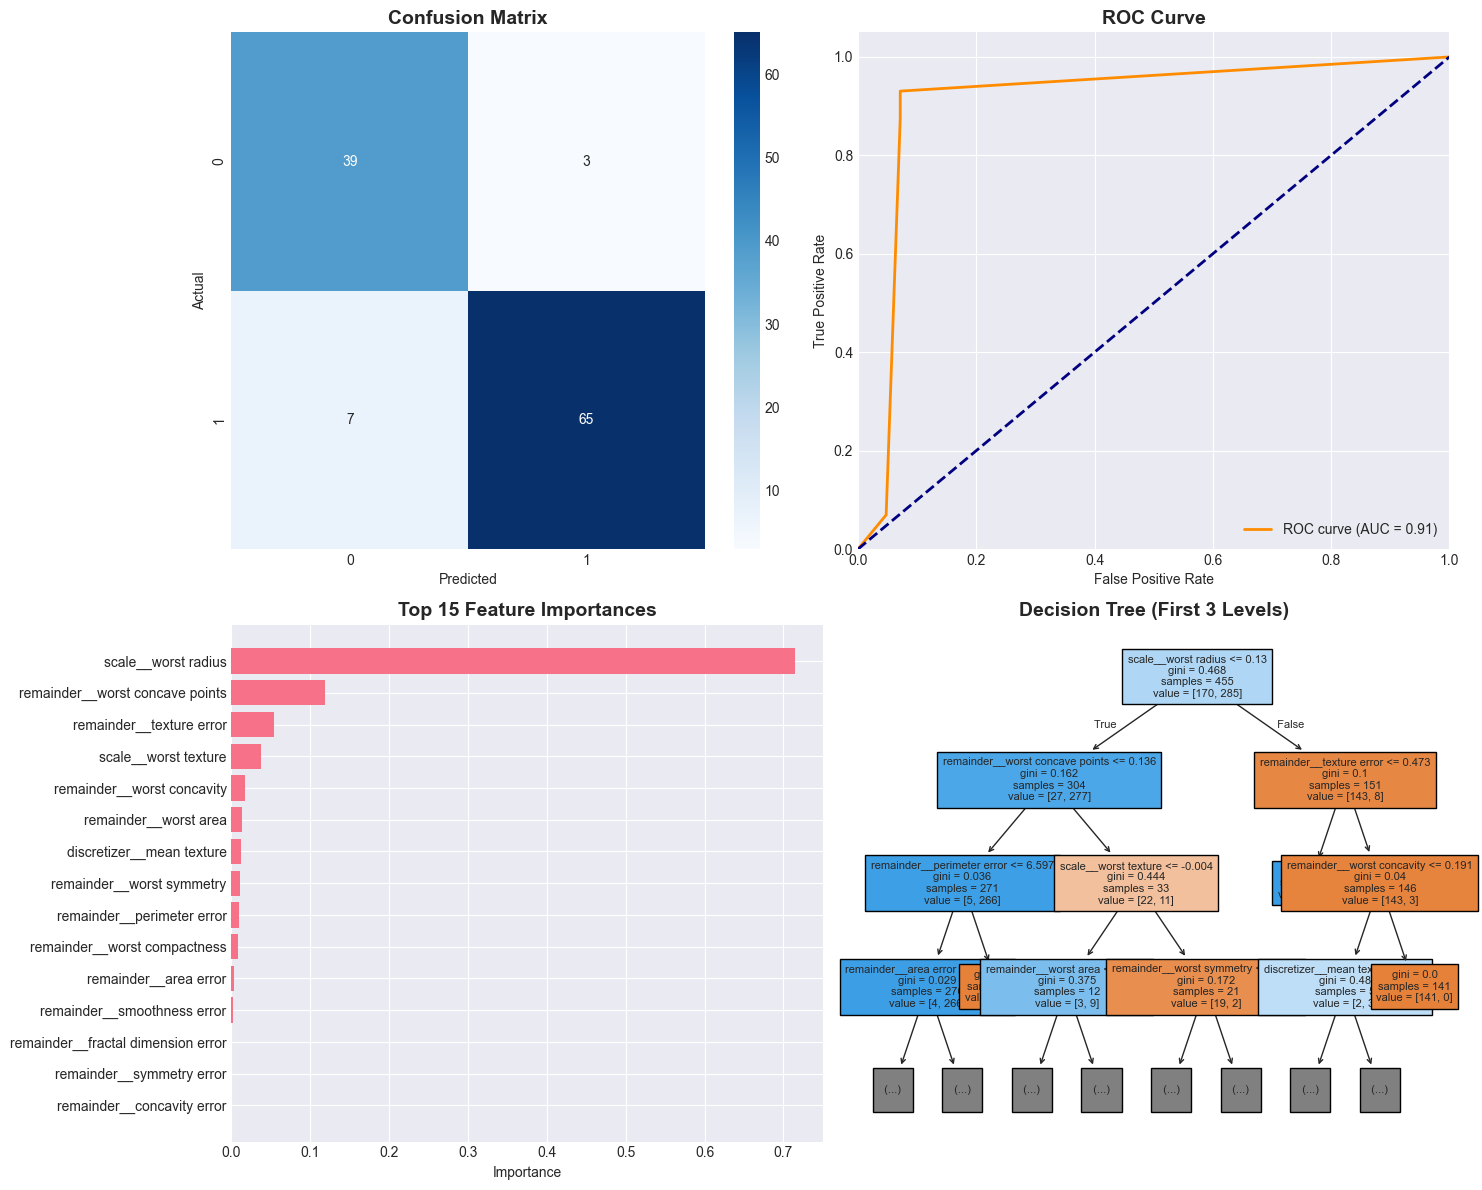

In [39]:
# MAIN EXECUTION

if __name__ == '__main__':
    # Initialize and run the Ml Pipeline
    ml_pipeline = MLPipelineWithDiscretization(random_state=RANDOM_STATE)
    ml_pipeline.run_full_pipeline()

    # Example: Making predictions on new data
    print("\n" + "="*80)
    print("BONUS: MAKING PREDICTIONS ON NEW DATA")
    print("="*80)

    new_samples = ml_pipeline.X_test.head(3)
    predictions = ml_pipeline.predict_new_data(new_samples)

    print("\nSample Predictions:")
    print(predictions)
    print("\nActual Labels:")
    print(ml_pipeline.y_test.head(3).values)

    print("\n" + "="*80)
    print("PIPELINE TUTORIAL COMPLETED!")
    print("="*80)
    print("""
    Key Industry Standards Demonstrated:
    ✓ Class-based architecture for reusability
    ✓ ColumnTransformer for feature-specific preprocessing
    ✓ Pipeline for reproducibility
    ✓ Train-test split with stratification
    ✓ Grid search for hyperparameter tuning
    ✓ Cross-validation for robust evaluation
    ✓ Comprehensive metrics and visualizations
    ✓ Documentation and logging
    ✓ Random state for reproducibility
    ✓ Production-ready prediction interface
    """)